Importing packages and libraries

In [115]:
import pandas as pd

Loading the dataset

In [116]:
data = pd.read_csv("heart.csv")

Printing the first 10  rows

In [117]:
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Shape of the data

In [118]:
data.shape

(918, 12)

Data types

In [119]:
data.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Checking for missing values

In [120]:
data.isna()
# can also be done with data.isnull()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
913,False,False,False,False,False,False,False,False,False,False,False,False
914,False,False,False,False,False,False,False,False,False,False,False,False
915,False,False,False,False,False,False,False,False,False,False,False,False
916,False,False,False,False,False,False,False,False,False,False,False,False


In [121]:
data.isnull().sum()
# data.isnull().any() for boolean

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Checking for Cholestrol and RestingBP

- When we have missing values with categorical, impute with the mode and for numerical if it is normally distributed impute with the mean and if it is skewed impute with the median.

- We can also drop all the missing values

In [122]:
data[data["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [123]:
data[data['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


Calculating median for non zeros

In [124]:
non_zero = data.loc[data['Cholesterol'] != 0, 'Cholesterol']
non_zero_median = non_zero.median()
data.loc[data['Cholesterol'] == 0, 'Cholesterol'] = non_zero_median

In [125]:
non_zero_BP = data.loc[data['RestingBP'] != 0, 'RestingBP']
non_zero_BP_median = non_zero_BP.median()
data.loc[data['RestingBP'] == 0, 'RestingBP'] = non_zero_BP_median

Class distribution of the Heart Disease

In [126]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

Visualising

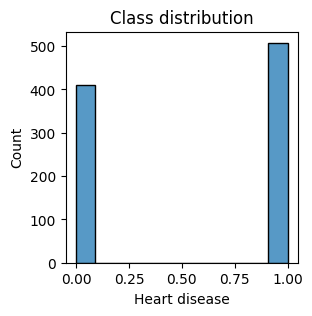

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(3,3))
sns.histplot(x='HeartDisease', data=data)
plt.title("Class distribution")
plt.xlabel("Heart disease")

plt.show()

Summary Statisitics

In [128]:
data.describe(include='all') # For all the data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.538126,243.204793,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,17.990127,53.401297,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,80.000000,85.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,214.000000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,237.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [129]:
data.describe() # For numerical data only the data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.990127,53.401297,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Statistical Analysis & Visualization Guide

| $y$ Variable | $x$ Variable | Recommended Visualization | Statistical Test |
|:---|:---|:---|:---|
| **Numerical** | **Categorical** | Box Plot | ANOVA (or t-test) |
| **Numerical** | **Numerical** | Scatter Plot | Correlation |
| **Categorical** | **Categorical** | Bar Chart | Chi-Square Test |


In [130]:
numerical_data = data.select_dtypes(exclude="object")
numerical_data.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.263054,0.045535,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.263054,1.000000,0.086079,0.067896,-0.109771,0.174130,0.117798
Cholesterol,0.045535,0.086079,1.000000,0.024917,-0.001600,0.054500,0.076114
FastingBS,0.198039,0.067896,0.024917,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.109771,-0.001600,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.174130,0.054500,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.117798,0.076114,0.267291,-0.400421,0.403951,1.000000


<Axes: >

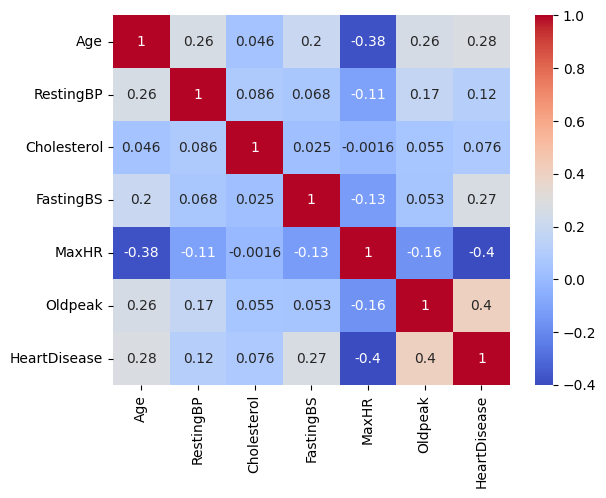

In [133]:
sns.heatmap(numerical_data.corr(), annot = True, cmap = "coolwarm")

Encoding data

In [135]:
data = pd.get_dummies(data, drop_first = True, dtype = int)

In [136]:
data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [137]:
data.isnull().sum()

Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
HeartDisease         0
Sex_M                0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_Y     0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

In [142]:
from sklearn.model_selection import train_test_split
ml_data = data.copy()
X = ml_data.drop(columns=["HeartDisease"])
y = ml_data["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)


Training a decision tree model

In [145]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, None]

for depth in depths:
    dtc = DecisionTreeClassifier(max_depth = depth)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Depth: {depth} accuracy: {accuracy:.3}")

Depth: 3 accuracy: 0.837
Depth: 5 accuracy: 0.783
Depth: None accuracy: 0.728


In [152]:
from sklearn.linear_model import LogisticRegression

lr= LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic regression accuracy: {accuracy:.3}")


Logistic regression accuracy: 0.853


c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [150]:
from sklearn.svm import SVC

svc= SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, svc_pred)
print(f"SVM accuracy: {accuracy:.3}")

SVM accuracy: 0.658


In [151]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, rfc_pred)
print(f"Random forest accuracy: {accuracy:.3}")

Random forest accuracy: 0.864
